In [1]:
# EDA & Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Modelling
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from scipy.stats import zscore

np.random.seed(42)
sns.set_style("whitegrid")
# df = pd.read_csv('../data/CAR DETAILS FROM CAR DEKHO.csv')
df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
df.shape

(4340, 8)

# Exploratory Data Analysis

In [2]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [4]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [5]:
df.corr(numeric_only=True)

,year,selling_price,km_driven
year,1.000000,0.413922,-0.419688
selling_price,0.413922,1.000000,-0.192289
km_driven,-0.419688,-0.192289,1.000000


In [6]:
df['transmission'].value_counts()

,count
transmission,
Manual,3892
Automatic,448


In [7]:
df['year'].unique()

array([2007, 2012, 2017, 2014, 2016, 2015, 2018, 2019, 2013, 2011, 2010,
       2009, 2006, 1996, 2005, 2008, 2004, 1998, 2003, 2002, 2020, 2000,
       1999, 2001, 1995, 1997, 1992])

In [8]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


## Data Visualisation

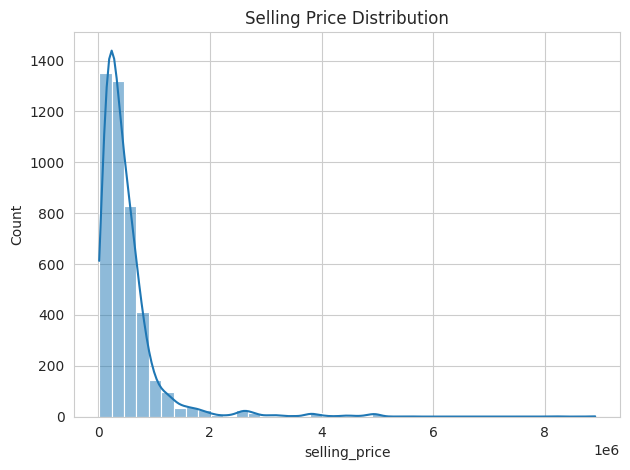

In [9]:
plt.figure()
sns.histplot(df['selling_price'], kde=True, bins=40)
plt.title('Selling Price Distribution')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'KM Driven Distribution')

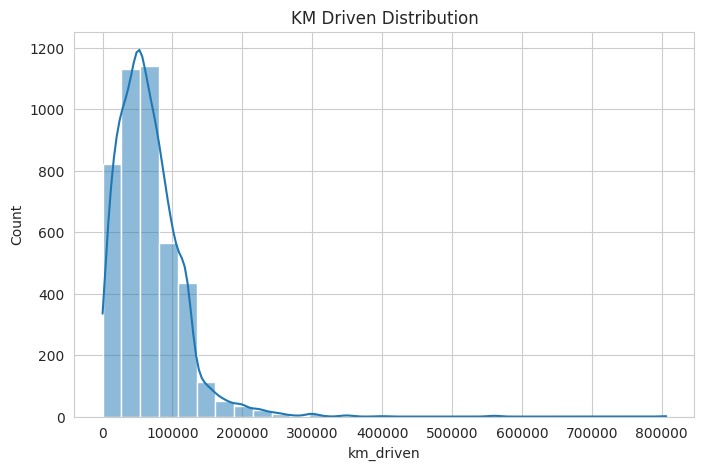

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['km_driven'], kde=True, bins=30)
plt.title('KM Driven Distribution')

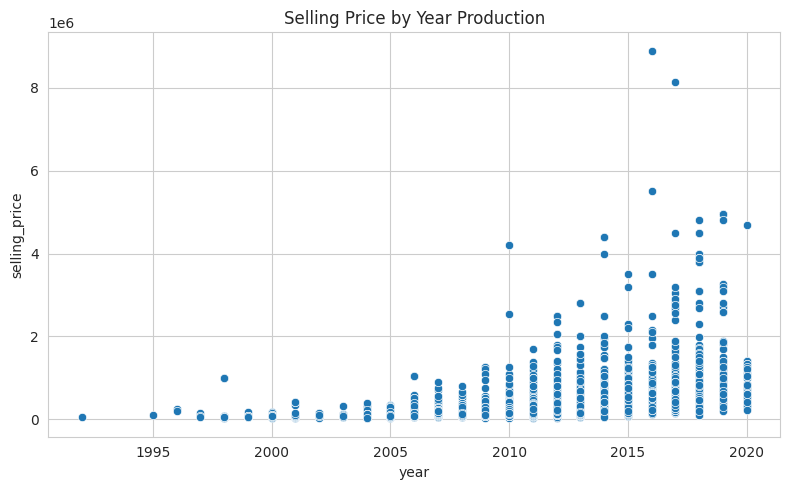

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='year', y='selling_price')
plt.title('Selling Price by Year Production')
plt.tight_layout()
plt.show()

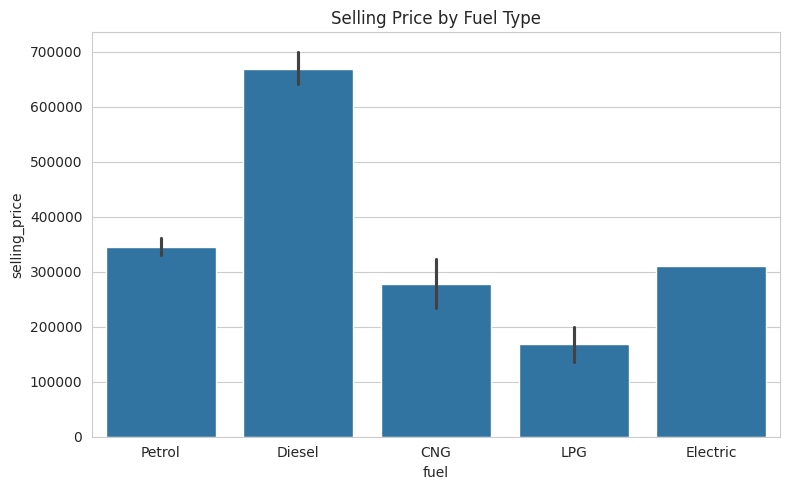

In [12]:
plt.figure(figsize=(8, 5))
sns.barplot(x='fuel', y='selling_price', data=df)
plt.title('Selling Price by Fuel Type')
plt.tight_layout()
plt.show()

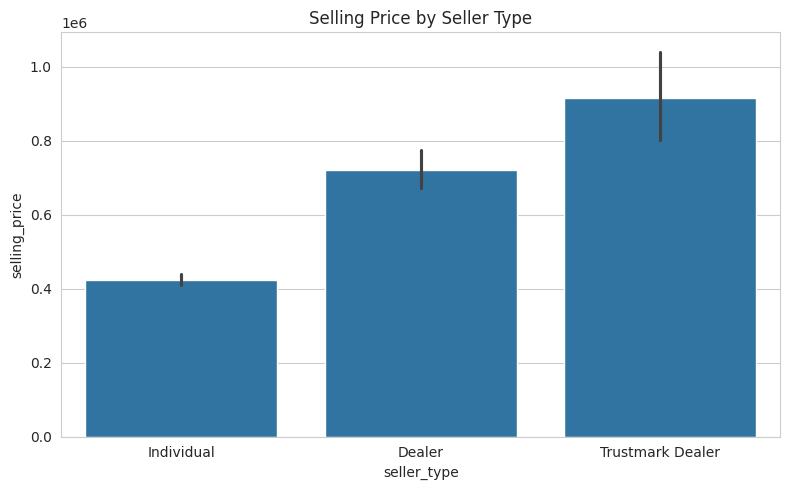

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(x='seller_type', y='selling_price', data=df)
plt.title('Selling Price by Seller Type')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Selling Price by Transmission')

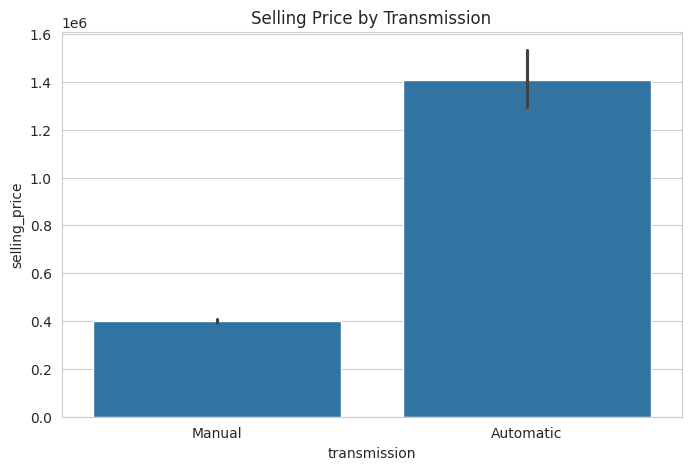

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='transmission', y='selling_price', data=df)
plt.title('Selling Price by Transmission')

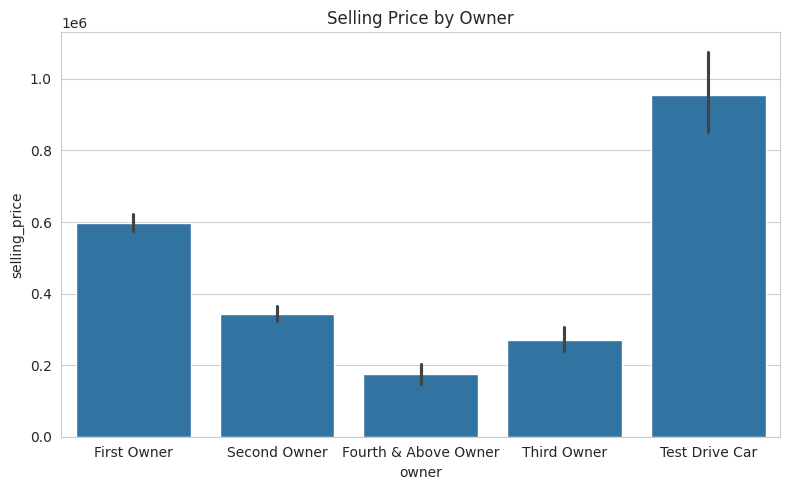

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x='owner', y='selling_price', data=df)
plt.title('Selling Price by Owner')
plt.tight_layout()
plt.show()

## Checking and Handling Outlier

In [20]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['year', 'selling_price', 'km_driven'], dtype='object')

In [21]:
num_cols = num_cols.drop('year')
num_cols

Index(['selling_price', 'km_driven'], dtype='object')

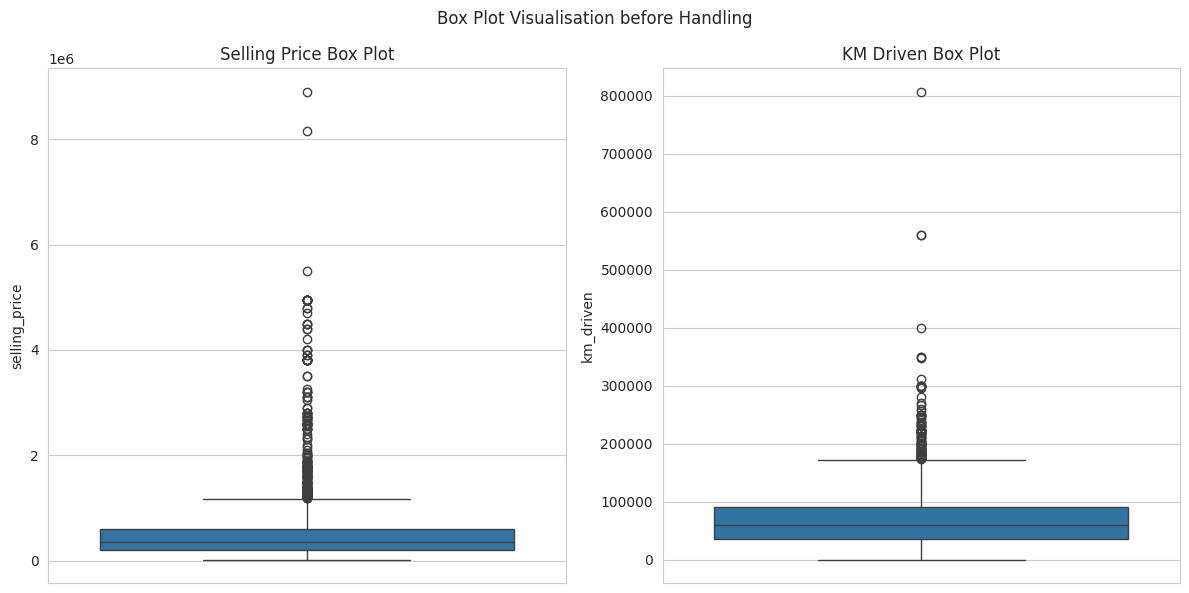

In [22]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.boxplot(ax=ax[0], data=df['selling_price'])
ax[0].set(title='Selling Price Box Plot')

sns.boxplot(ax=ax[1], data=df['km_driven'])
ax[1].set(title='KM Driven Box Plot')
fig.suptitle('Box Plot Visualisation before Handling')
plt.tight_layout()
plt.show()

## Z Score Handling

In [23]:
# Find Z-score
z_scores = zscore(df[num_cols])

# Detect outlier by column
outliers = np.abs(z_scores) > 3

# Check total outlier by column
print(pd.DataFrame(outliers, columns=num_cols).sum())

# find what rows that have outlier
data_outlier_rows = df[(outliers).any(axis=1)]
print(data_outlier_rows)

# Trimming
is_outlier_row = outliers.any(axis=1)
df_clean = df[~is_outlier_row]

# print
print("Rows before trimming:", len(df))
print("Rows after trimming:", len(df_clean))
print(f"Dropped persentage: {(1 - len(df_clean)/len(df))*100:.1f}%")

selling_price    92
km_driven        55
dtype: int64
                                                   name  year  selling_price  \
69        Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII  2010         280000   
70                     Toyota Corolla Altis Diesel D4DG  2011         350000   
89    Mercedes-Benz S-Class S 350d Connoisseurs Edition  2017        8150000   
96                                      Audi A8 4.2 TDI  2013        2800000   
101          Mercedes-Benz E-Class Exclusive E 200 BSIV  2018        4500000   
...                                                 ...   ...            ...   
4255                             Mahindra XUV500 W8 2WD  2014         650000   
4275                             Mahindra XUV500 W8 2WD  2014         650000   
4286                             Fiat Punto 1.3 Emotion  2010         130000   
4304                 Audi Q5 3.0 TDI Quattro Technology  2018        3899000   
4313                 Ford Endeavour 2.2 Titanium AT 4X2  2019      

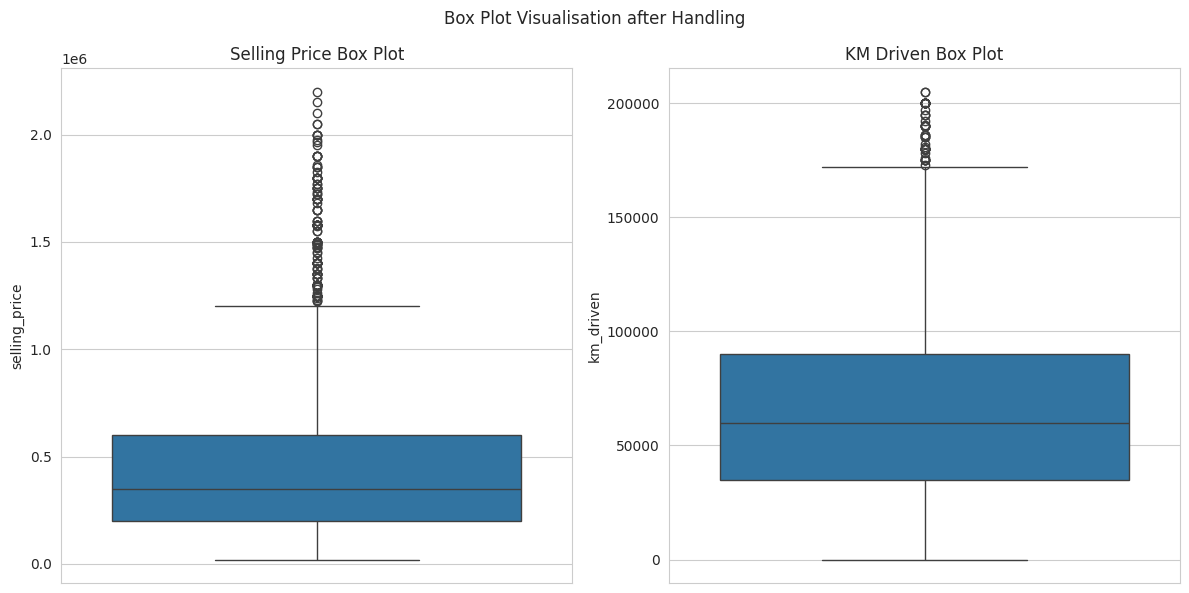

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
sns.boxplot(ax=ax[0], data=df_clean['selling_price'])
ax[0].set(title='Selling Price Box Plot')

sns.boxplot(ax=ax[1], data=df_clean['km_driven'])
ax[1].set(title='KM Driven Box Plot')

fig.suptitle('Box Plot Visualisation after Handling')
plt.tight_layout()
plt.show()

## IQR

In [25]:
# outlier_summary = {}
# df_clean = df.copy()

# for col in num_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     outliers = ((df[col] < lower) | (df[col] > upper)).sum()
#     outlier_summary[col] = outliers
#     df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

# print("Number of outliers per column before handling:")
# for k, v in outlier_summary.items():
#     print(f"{k}: {v}")

In [26]:
# print("nrows before drop:", len(df))
# print("nrows after drop:", len(df_clean))
# print(f"dropped data percentage: {(1 - len(df_clean)/len(df))*100:.1f}%")

In [27]:
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
# sns.boxplot(ax=ax[0], data=df_clean['selling_price'])
# ax[0].set(title='Selling Price Box Plot')

# sns.boxplot(ax=ax[1], data=df_clean['km_driven'])
# ax[1].set(title='KM Driven Box Plot')

# fig.suptitle('Box Plot Visualisation after Handling')
# plt.tight_layout()
# plt.show()

# Data Preprocessing

In [28]:
# creating a pipeline
cat_feat = ['fuel', 'seller_type', 'transmission', 'owner']

preprocessor = ColumnTransformer(
    transformers = [
        ('onehot',  OneHotEncoder(handle_unknown='ignore'), cat_feat)
    ], remainder='passthrough'
)

In [29]:
# Data Splitting
X = df_clean.drop(['selling_price', 'name'], axis=1)
y = df_clean['selling_price']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3354, 6), (839, 6), (3354,), (839,))

# Modelling

In [30]:
regression_model = {'Lasso': Lasso(),
                    'LinearRegression': LinearRegression(),
                    'RandomForestRegressor': RandomForestRegressor()}
model_result = {}

In [31]:
for model_name, model in regression_model.items():
    model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('model', model)])
    print(f'Fitting Model {model_name}...')
    model_pipeline.fit(X_train, y_train)

    print(f'Scoring {model_name}...')
    model_result[model_name] = model_pipeline.score(X_test, y_test)

Fitting Model Lasso...
Scoring Lasso...
Fitting Model LinearRegression...
Scoring LinearRegression...
Fitting Model RandomForestRegressor...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.432e+11, tolerance: 3.655e+10
  model = cd_fast.enet_coordinate_descent(


Scoring RandomForestRegressor...


In [32]:
model_result

{'Lasso': 0.5041733962700247,
 'LinearRegression': 0.5041710857571589,
 'RandomForestRegressor': 0.588712346662259}

# Hyper Parameter Tunning

Random Search Cross Validation

In [33]:
rf_reg_rs = Pipeline(steps=[('preprocessor', preprocessor),
                            ('model', RandomForestRegressor())])

param_distribution = {'model__n_estimators': [100, 200, 500, 1000],
                      'model__max_depth': [None, 5, 10, 20, 30],
                      'model__max_features': ['sqrt', 'log2', None]}

rf_rdcv = RandomizedSearchCV(
    estimator=rf_reg_rs,
    param_distributions=param_distribution,
    n_iter=5,
    cv=5,
    verbose=2,
    random_state=42
)

rf_rdcv.fit(X_train, y_train)
rf_rdcv.score(X_test, y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.4s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   0.9s
[CV] END model__max_depth=None, model__max_features=log2, model__n_estimators=200; total time=   0.9s
[CV] END model__max_de

0.6077068489131865

In [34]:
rf_rdcv.best_params_

{'model__n_estimators': 100,
 'model__max_features': 'sqrt',
 'model__max_depth': 20}

In [35]:
param_grid = {'model__n_estimators': [1, 100, 200],
                      'model__max_depth': [None, 5],
                      'model__max_features': ['sqrt', 'log2']}

rf_gscv = GridSearchCV(
    estimator=rf_reg_rs,
    param_grid=param_grid,
    cv=5,
    verbose=2,
)

rf_gscv.fit(X_train, y_train)
rf_gscv.score(X_test, y_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=1; total time=   0.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=None, model__max_features=sqrt, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=None,

0.6032942153061607